# 06 — Seizure Detection using ARIMA Residuals

**Mục tiêu của Notebook này:**
1. **Khởi tạo và Huấn luyện (Fit):** Đưa bộ tham số $(p, d, q)$ thu được từ Notebook 05 vào mô hình `ARIMA` của `statsmodels`. Huấn luyện mô hình trên chuỗi thời gian RMS.
2. **Trích xuất Sai số (Residuals):** Tính toán mảng sai số: $Residual = \text{Giá trị thực tế} - \text{Giá trị dự báo}$.
3. **Thiết lập Ngưỡng (Thresholding):** Đặt một ngưỡng thống kê (ví dụ: `Ngưỡng = Trung bình sai số + 3 * Độ lệch chuẩn`). 
4. **Phát hiện (Detection):** Các khoảng thời gian (cửa sổ) có sai số vượt qua ngưỡng này sẽ được thuật toán đánh dấu là có khả năng xảy ra cơn động kinh.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Tùy chỉnh hiển thị
plt.rcParams.update({'figure.dpi': 120})

# Đọc file CSV chứa chuỗi thời gian RMS (tạo ra từ Notebook 04)
input_file = "ds003029_arima_input_timeseries.csv"
df = pd.read_csv(input_file)

print(f"Đã load {len(df)} cửa sổ thời gian (windows).")

Đã load 152 cửa sổ thời gian (windows).


## Bước 1: Khởi tạo mô hình và Huấn luyện (Fit ARIMA)
Chúng ta sẽ truyền tham số `order=(p, d, q)` vào mô hình. 
*(Lưu ý: Trong code dưới đây, mình đang đặt tạm p=2, d=1, q=2. Bạn HÃY THAY ĐỔI bộ số này bằng chính kết quả bạn đọc được từ biểu đồ ACF/PACF ở Notebook 05 nhé!)*

In [2]:
# CHÚ Ý: Thay đổi p, d, q theo kết quả phân tích của bạn ở Notebook 05
p, d, q = 2, 1, 2 

print(f"Đang huấn luyện ARIMA({p},{d},{q})... (Có thể mất vài chục giây)")

# Khởi tạo và fit mô hình
model = ARIMA(df['rms'], order=(p, d, q))
model_fit = model.fit()

# Trích xuất phần dư (Residuals)
# Lấy trị tuyệt đối vì sai số có thể âm hoặc dương, ta chỉ quan tâm độ lớn của sai lệch
df['residuals'] = np.abs(model_fit.resid)

print("Huấn luyện xong! Đây là tóm tắt mô hình:")
print(model_fit.summary().tables[1])

Đang huấn luyện ARIMA(2,1,2)... (Có thể mất vài chục giây)
Huấn luyện xong! Đây là tóm tắt mô hình:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2977      0.053      5.601      0.000       0.194       0.402
ar.L2         -0.7009      0.055    -12.818      0.000      -0.808      -0.594
ma.L1         -1.1685      0.029    -39.991      0.000      -1.226      -1.111
ma.L2          0.8397      0.031     27.192      0.000       0.779       0.900
sigma2      2.905e-08   5.74e-09      5.062      0.000    1.78e-08    4.03e-08


/mnt/c/Users/DELL/Seizure-Dectection-using-ECoG-/sz_venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Bước 2: Đặt ngưỡng (Threshold) và Phát hiện Động kinh (Anomaly Detection)
Dựa trên phân phối chuẩn, khoảng 99.7% dữ liệu bình thường sẽ nằm trong khoảng 3 độ lệch chuẩn (Standard Deviation - std). 
Chúng ta sẽ đặt ngưỡng báo động bằng: **$\mu + 3\sigma$** (Trung bình + 3 * Độ lệch chuẩn của bộ sai số). Bất kỳ điểm nào vọt qua đường này sẽ bị gán nhãn là Động kinh (Seizure = 1).

Ngưỡng phát hiện (Threshold): 0.0006


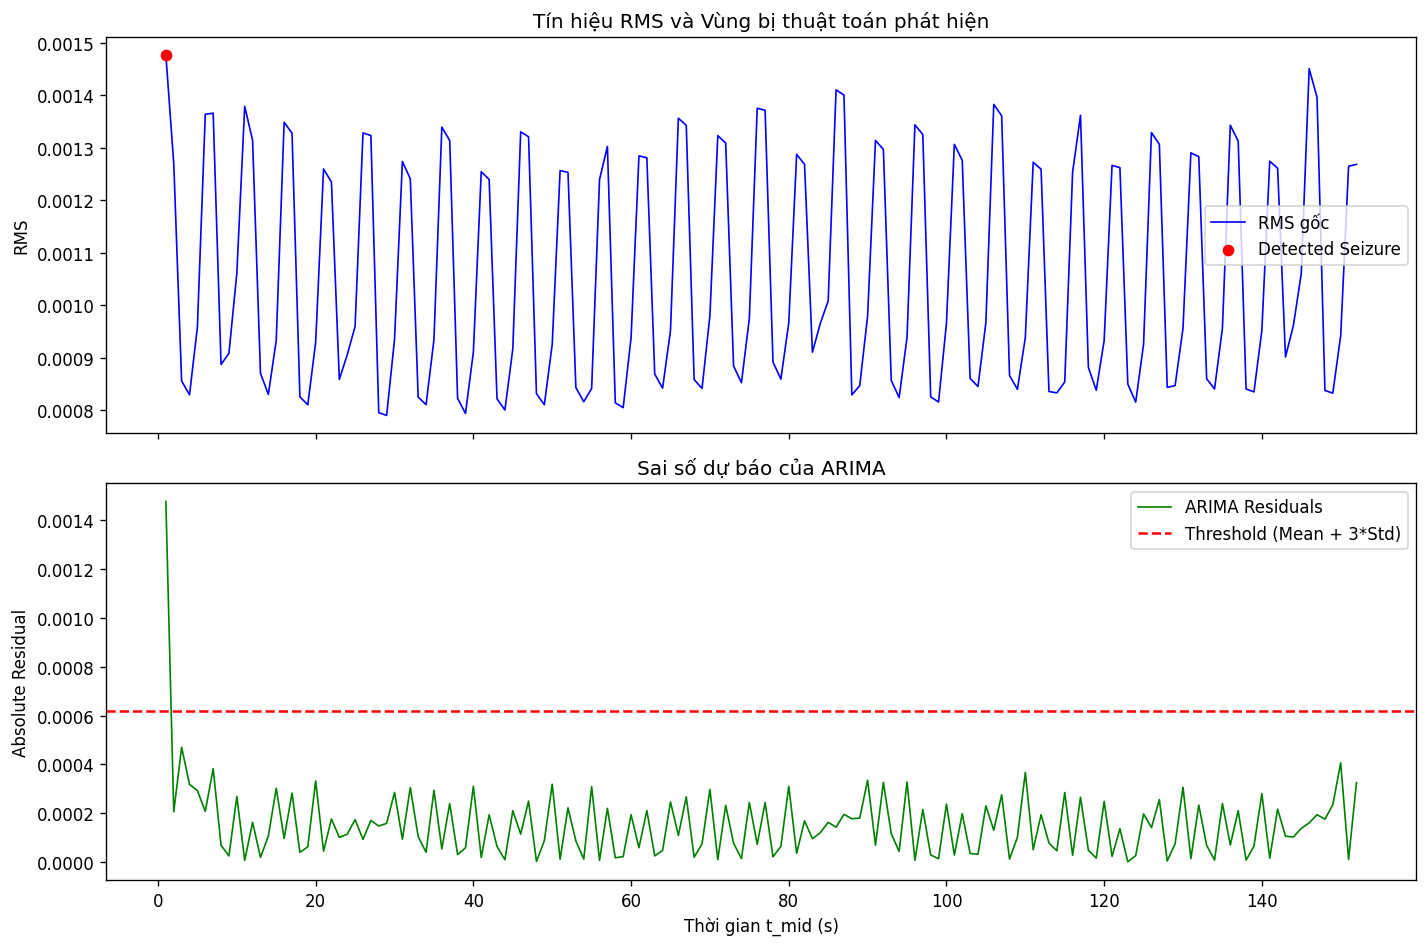

Tổng số cửa sổ (windows) phát hiện có động kinh: 1


In [3]:
# Tính toán ngưỡng (Threshold)
res_mean = df['residuals'].mean()
res_std = df['residuals'].std()
K = 3 # Hệ số nhân (Có thể tinh chỉnh: 2, 3, hoặc 4 tùy độ nhạy mong muốn)

threshold = res_mean + K * res_std
print(f"Ngưỡng phát hiện (Threshold): {threshold:.4f}")

# Gán nhãn phát hiện: True (Động kinh) / False (Bình thường)
df['is_seizure_detected'] = df['residuals'] > threshold

# Trực quan hóa kết quả
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Chuỗi RMS gốc và các điểm bị thuật toán bắt được
axes[0].plot(df['t_mid_s'], df['rms'], color='blue', label='RMS gốc', linewidth=1)
# Đánh dấu các điểm phát hiện được bằng chấm đỏ
detected_points = df[df['is_seizure_detected']]
axes[0].scatter(detected_points['t_mid_s'], detected_points['rms'], color='red', label='Detected Seizure', zorder=5)
axes[0].set_title('Tín hiệu RMS và Vùng bị thuật toán phát hiện')
axes[0].set_ylabel('RMS')
axes[0].legend()

# Plot 2: Biểu đồ Sai số (Residuals) và Đường Ngưỡng (Threshold)
axes[1].plot(df['t_mid_s'], df['residuals'], color='green', label='ARIMA Residuals', linewidth=1)
axes[1].axhline(y=threshold, color='red', linestyle='--', label=f'Threshold (Mean + {K}*Std)')
axes[1].set_title('Sai số dự báo của ARIMA')
axes[1].set_xlabel('Thời gian t_mid (s)')
axes[1].set_ylabel('Absolute Residual')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Tổng số cửa sổ (windows) phát hiện có động kinh: {df['is_seizure_detected'].sum()}")

## Bước 3: Đánh giá Hiệu năng Thuật toán (Model Evaluation)
Chúng ta sẽ đối chiếu cột dự đoán `is_seizure_detected` (dựa trên sai số ARIMA) với cột nhãn thực tế `y` (Ground Truth) được tạo ra từ khoảng thời gian `onset_s` và `offset_s` ở Notebook 03.

**Các khái niệm cốt lõi:**
* **True Positive (TP):** Thuật toán báo động kinh, và thực tế ĐÚNG là động kinh.
* **False Positive (FP):** Thuật toán báo động kinh, nhưng thực tế là BÌNH THƯỜNG (Báo động giả / False Alarm).
* **False Negative (FN):** Thuật toán báo bình thường, nhưng thực tế ĐANG CÓ ĐỘNG KINH (Bỏ sót / Rất nguy hiểm!).
* **True Negative (TN):** Thuật toán báo bình thường, và thực tế bình thường.

In [8]:
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Setup module paths nội bộ của project (giống các notebook trước)
ws = Path.cwd().resolve()
src_dir = ws / 'src'
if not src_dir.exists() and (ws.parent / 'src').exists():
    ws = ws.parent
src_dir = (ws / 'src').resolve()
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from ds003029_eda.paths import get_paths
paths = get_paths()

# 2. Load Ground Truth từ thư mục eda_outputs
gt_file = paths.outputs_dir / "ds003029_window_features_demo.csv"
print(f"Đang đọc file Ground Truth từ: {gt_file}")
df_gt = pd.read_csv(gt_file)

# Lọc chỉ lấy 2 cột cần thiết: t_mid_s và y
df_gt = df_gt[['t_mid_s', 'y']]

# 3. Ghép (Merge) nhãn thực tế vào DataFrame hiện tại dựa trên mốc thời gian t_mid_s
df_eval = pd.merge(df, df_gt, on='t_mid_s', how='inner')

# 4. Chuẩn bị mảng nhãn dự đoán và nhãn thực tế
# Chuyển đổi True/False của is_seizure_detected thành 1/0
y_pred = df_eval['is_seizure_detected'].astype(int) 
y_true = df_eval['y']

print(f"Đã ghép nối thành công! Tổng số mẫu để đánh giá: {len(df_eval)}")

Đang đọc file Ground Truth từ: /mnt/c/Users/DELL/eda_outputs/ds003029_window_features_demo.csv
Đã ghép nối thành công! Tổng số mẫu để đánh giá: 152


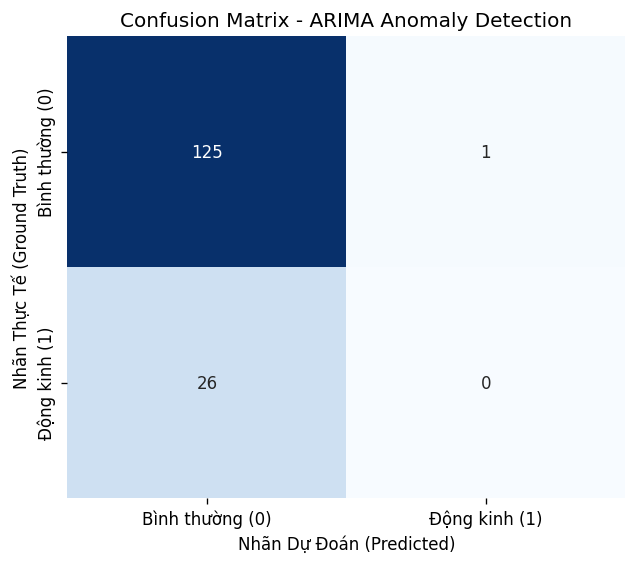

================ BÁO CÁO HIỆU NĂNG ================
                 precision    recall  f1-score   support

Bình thường (0)       0.83      0.99      0.90       126
  Động kinh (1)       0.00      0.00      0.00        26

       accuracy                           0.82       152
      macro avg       0.41      0.50      0.45       152
   weighted avg       0.69      0.82      0.75       152

Số lần bắt trúng động kinh (TP): 0
Số lần báo động giả (FP): 1
Số lần bỏ sót động kinh (FN): 26  <-- CẦN TỐI THIỂU HÓA CHỈ SỐ NÀY!
Số lần nhận diện đúng bình thường (TN): 125


In [9]:
# 4. Tính toán Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Vẽ biểu đồ Heatmap cho Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bình thường (0)', 'Động kinh (1)'],
            yticklabels=['Bình thường (0)', 'Động kinh (1)'])
plt.title('Confusion Matrix - ARIMA Anomaly Detection')
plt.ylabel('Nhãn Thực Tế (Ground Truth)')
plt.xlabel('Nhãn Dự Đoán (Predicted)')
plt.show()

# 5. In báo cáo chi tiết (Classification Report)
print("================ BÁO CÁO HIỆU NĂNG ================")
print(classification_report(y_true, y_pred, target_names=['Bình thường (0)', 'Động kinh (1)']))

# In ra số liệu cụ thể để phân tích
TN, FP, FN, TP = cm.ravel()
print(f"Số lần bắt trúng động kinh (TP): {TP}")
print(f"Số lần báo động giả (FP): {FP}")
print(f"Số lần bỏ sót động kinh (FN): {FN}  <-- CẦN TỐI THIỂU HÓA CHỈ SỐ NÀY!")
print(f"Số lần nhận diện đúng bình thường (TN): {TN}")